# Vehicle Dataset from CarDekho

## Dataset Overview
This dataset contains information about used cars listed on CarDekho, one of India's leading car search platforms. It includes details about vehicle specifications, pricing, and ownership history.

**Source:** [Kaggle - Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)


## Data Dictionary

| Column | Data Type | Description |
|--------|-----------|-------------|
| **name** | object | Complete name and model of the vehicle |
| **year** | int64 | Manufacturing year of the vehicle |
| **selling_price** | int64 | Current selling price (in INR) |
| **km_driven** | int64 | Total kilometers driven by the vehicle |
| **fuel** | object | Fuel type (Petrol, Diesel, CNG, LPG, Electric) |
| **seller_type** | object | Type of seller (Individual, Dealer, Trustmark Dealer) |
| **transmission** | object | Transmission type (Manual, Automatic) |
| **owner** | object | Ownership history (First Owner, Second Owner, etc.) |


## Dataset Statistics
- **Total Records:** 4,340 vehicles
- **Time Period:** Various years (check `year` column for range)
- **No Missing Values:** All columns are complete (4,340 non-null entries)


## Potential Analysis Questions
- What factors most influence vehicle selling price?
- How does depreciation vary by brand, fuel type, or transmission?
- What's the relationship between km_driven and selling_price?
- Which seller types offer better deals?
- How does ownership history affect pricing?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Getting the data - loading Df

In [2]:
vehicles_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/vehicles/data/CAR%20DETAILS%20FROM%20CAR%20DEKHO.csv"
vehicles = pd.read_csv(vehicles_url, usecols=lambda col: not col.startswith("Unnamed"))

In [3]:
vehicles

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


### Data inspection / EDA (Exploratory Data Analysis)

In [4]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


#### Numeric columns

In [5]:
vehicles.select_dtypes("number").describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Categorical columns

In [6]:
for col in ["fuel", "seller_type", "transmission", "owner"]:
    display(vehicles[col].value_counts(normalize=True, dropna=False).head(15).round(5))

fuel
Diesel      0.49608
Petrol      0.48917
CNG         0.00922
LPG         0.00530
Electric    0.00023
Name: proportion, dtype: float64

seller_type
Individual          0.74747
Dealer              0.22903
Trustmark Dealer    0.02350
Name: proportion, dtype: float64

transmission
Manual       0.89677
Automatic    0.10323
Name: proportion, dtype: float64

owner
First Owner             0.65253
Second Owner            0.25484
Third Owner             0.07005
Fourth & Above Owner    0.01866
Test Drive Car          0.00392
Name: proportion, dtype: float64

### Target Distribution

In [7]:
sns.set_color_codes("bright")

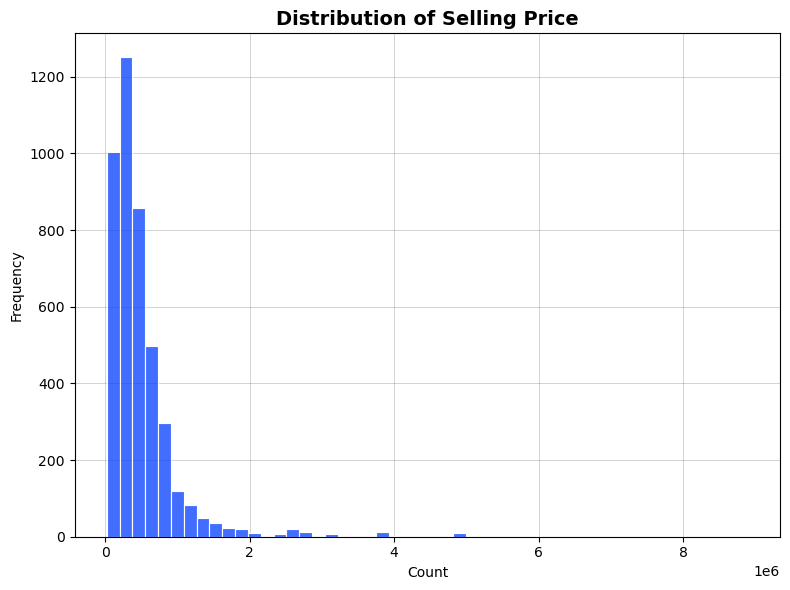

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=vehicles, x="selling_price", color="b", edgecolor="white", ax=ax, bins=50
)
ax.set(xlabel="Count", ylabel="Frequency")
ax.set_title("Distribution of Selling Price", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Train set / Test set split

In [9]:
from sklearn.model_selection import train_test_split

vehicles_full = vehicles.copy()

X = vehicles_full.drop(columns="selling_price")
y = vehicles_full["selling_price"]

# Stratify the split by binned target to keep the price distribution similar
# in both train and test sets (more stable, fairer offline evaluation).
price_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins,
)


#### Plots

In [10]:
# Create training dataframe by combining X_train and y_train
vehicles_train = X_train.copy()
vehicles_train["selling_price"] = y_train

# Log-transform price (prices are right-skewed; use log1p for zeros)
vehicles_train["log_price"] = np.log1p(vehicles_train["selling_price"])


# Sort categories by median price (intuitive order)
def median_order(col):
    return (
        vehicles_train.groupby(col)["log_price"]
        .median()
        .sort_values(ascending=False)
        .index
    )


cat_cols = ["fuel", "seller_type", "transmission", "owner"]
for col in cat_cols:
    vehicles_train[f"{col}_order"] = (
        vehicles_train[col]
        .astype("category")
        .cat.set_categories(median_order(col), ordered=True)
    )

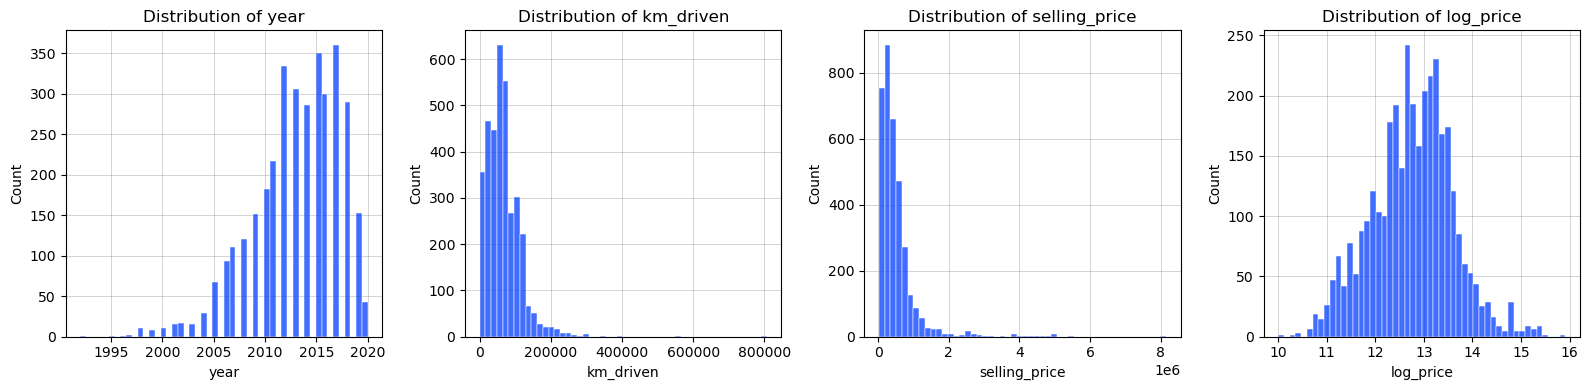

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

numeric_cols = [
    col
    for col in vehicles_train.select_dtypes("number").columns
    if col in ["year", "selling_price", "km_driven", "log_price"]
]
for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=vehicles_train, x=col, color="b", edgecolor="white", bins=50, ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(col)
    axes[i].grid(True, alpha=0.4, linewidth=0.6, color="grey")
    axes[i].set_axisbelow(True)


plt.tight_layout()
plt.show()

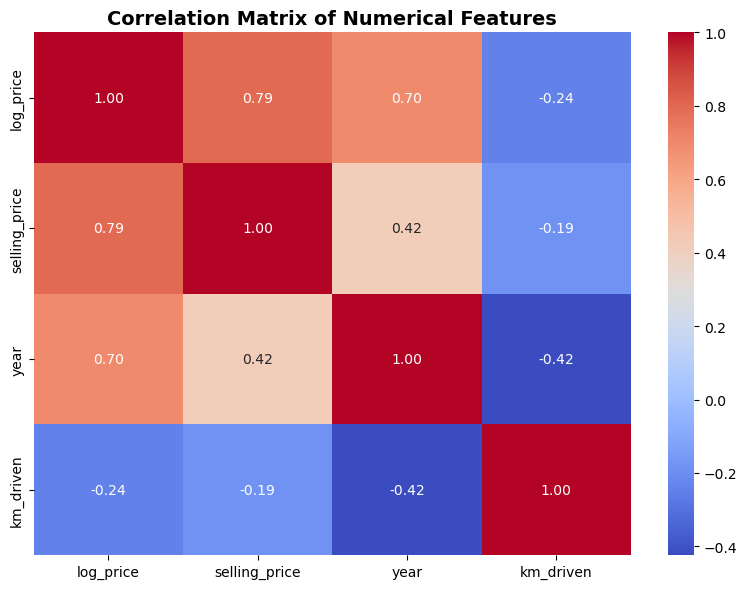

In [12]:
corr_matrix = vehicles_train[["log_price", "selling_price", "year", "km_driven"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix of Numerical Features", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

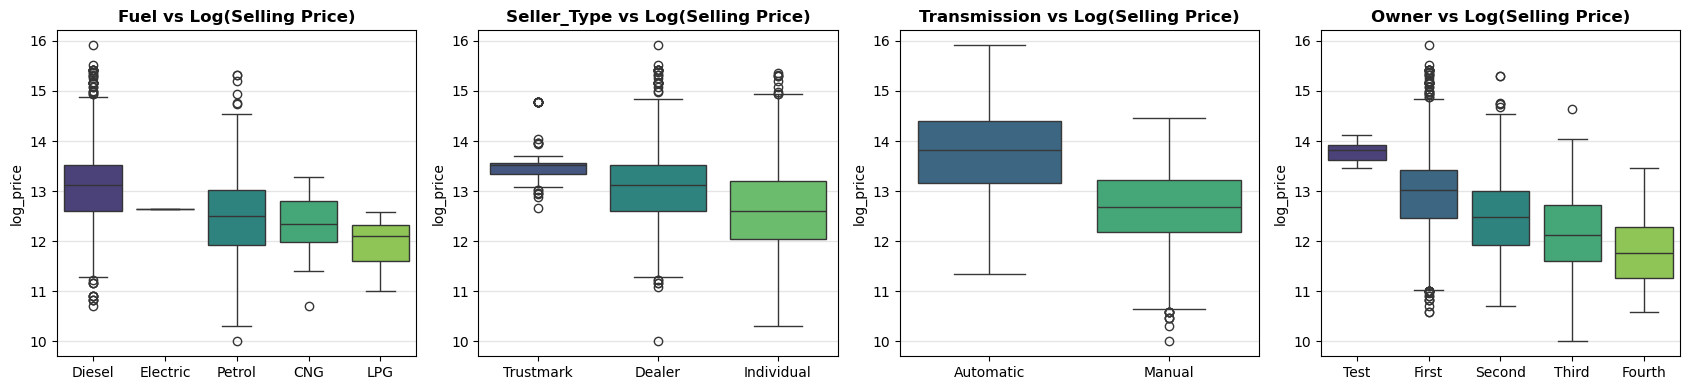

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    sns.boxplot(
        data=vehicles_train,
        x=col + "_order",
        y="log_price",
        hue=col + "_order",
        palette="viridis",
        ax=axes[i],
        legend=False,
    )
    axes[i].set_title(f"{col.title()} vs Log(Selling Price)", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.2, linewidth=1, color="grey")

    # Get current tick labels and modify them
    labels = [label.get_text().split()[0] for label in axes[i].get_xticklabels()]
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
order_cols = [col for col in vehicles_train.columns if col.endswith("_order")]
vehicles_train.drop(columns=order_cols, inplace=True)
print(f"Dropped: {order_cols}")

Dropped: ['fuel_order', 'seller_type_order', 'transmission_order', 'owner_order']


### Transformers / Pipelines 

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


# Custom transformer that converts manufacturing year to vehicle age
# - Linear relationship: each year of age has consistent depreciation impact
class YearToAgeTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        current_year: int = 2025,  # Reference year for age calculation
        year_col: str = "year",  # Input column containing manufacturing year
        output_col: str = "car_age",  # Output column name for calculated age
        drop_year: bool = True,  # Remove original year column to avoid redundancy
        min_age: int
        | None = 0,  # Floor for age values (handles future years or errors)
        max_age: int
        | None = 50,  # Ceiling for age values (handles outliers/vintage cars)
    ):
        self.current_year = current_year
        self.year_col = year_col
        self.output_col = output_col
        self.drop_year = drop_year
        self.min_age = min_age
        self.max_age = max_age

    # Fit method: validates input structure and stores metadata for sklearn compatibility
    def fit(self, X, y=None):
        # Ensure input is DataFrame (required for column-based operations)
        if not hasattr(X, "columns"):
            raise TypeError("YearToAgeTransformer expects a pandas DataFrame.")
        # Verify required column exists before transformation
        if self.year_col not in X.columns:
            raise ValueError(f"Column '{self.year_col}' not found in X.")

        # Store original feature names and count for scikit-learn pipeline compatibility
        # Required for feature name propagation through pipelines
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True  # Flag for check_is_fitted validation
        return self

    # Transform method: performs the actual year-to-age conversion
    def transform(self, X):
        # Verify transformer was fitted before transform (sklearn protocol)
        check_is_fitted(self, attributes="is_fitted_")
        X = X.copy()  # Avoid modifying original DataFrame

        # Convert to numeric, coercing invalid values to NaN (handles mixed types)
        year = pd.to_numeric(X[self.year_col], errors="coerce")
        # Calculate age as difference from current year
        age = self.current_year - year

        # Apply lower bound clipping (prevents negative ages from future years or data errors)
        if self.min_age is not None:
            age = age.clip(lower=self.min_age)
        # Apply upper bound clipping (prevents extreme ages from vintage/antique cars)
        if self.max_age is not None:
            age = age.clip(upper=self.max_age)

        # Create new age column
        X[self.output_col] = age

        # Optionally remove original year column to reduce feature redundancy
        if self.drop_year:
            X = X.drop(columns=[self.year_col])

        return X


# Custom transformer that extracts brand/manufacturer from full car name
# Theory: Brand captures manufacturer reputation, pricing tier, and quality perception
# Tradeoffs: Loses model-specific information; assumes first word is always brand (may fail for edge cases)
class BrandExtractor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        name_col: str = "name",  # Input column containing full car name
        output_col: str = "brand",  # Output column for extracted brand
        drop_name: bool = True,  # Remove original name to reduce dimensionality
        missing_value: str = "__MISSING__",  # Sentinel value for empty/invalid names
    ):
        self.name_col = name_col
        self.output_col = output_col
        self.drop_name = drop_name
        self.missing_value = missing_value

    # Fit method: validates DataFrame structure before extraction
    def fit(self, X, y=None):
        # Ensure input is DataFrame (required for column operations)
        if not hasattr(X, "columns"):
            raise TypeError("BrandExtractor expects a pandas DataFrame.")
        # Verify name column exists
        if self.name_col not in X.columns:
            raise ValueError(f"Column '{self.name_col}' not found in X.")

        # Store metadata for sklearn pipeline compatibility
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True
        return self

    # Transform method: extracts first word from car name as brand identifier
    def transform(self, X):
        # Verify transformer was fitted (sklearn protocol)
        check_is_fitted(self, attributes="is_fitted_")
        X = X.copy()  # Avoid modifying original DataFrame

        # Preprocessing: convert to string, fill NaN, strip whitespace, normalize spaces
        series = (
            X[self.name_col]
            .astype("string")  # Ensure string dtype for text operations
            .fillna("")  # Replace NaN with empty string
            .str.strip()  # Remove leading/trailing whitespace
            .str.replace(
                r"\s+", " ", regex=True
            )  # Collapse multiple spaces to single space
        )

        # Extract first word as brand, fill missing/empty with sentinel value
        brand = series.str.split(" ").str[0].fillna(self.missing_value)
        # Replace empty strings with missing value (handles stripped whitespace-only names)
        brand = brand.where(brand.ne(""), self.missing_value)

        # Create new brand column
        X[self.output_col] = brand

        # Optionally remove original name column (reduces high cardinality)
        if self.drop_name:
            X = X.drop(columns=[self.name_col])

        return X

In [16]:
from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Creates a feature engineering pipeline that transforms raw vehicle data into ML-ready features
def make_feature_engineering(current_year: int = 2025) -> Pipeline:
    # Create a feature engineering pipeline that applies transformations in order
    return Pipeline(
        steps=[
            # First step: extract brand name from full vehicle name (e.g., "Maruti 800 AC" → "Maruti")
            # Brand extraction must happen first since OneHotEncoder needs clean categorical values
            ("brand_extractor", BrandExtractor(drop_name=True)),
            # Second step: convert manufacturing year to car age (2025 - year)
            # Age is more interpretable than year and directly correlates with depreciation
            (
                "year_to_age",
                YearToAgeTransformer(current_year=current_year, drop_year=True),
            ),
        ]
    )


# Define which columns will be treated as categorical vs numerical
categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
numerical_cols = ["km_driven", "car_age"]


# Creates a pipeline for categorical feature preprocessing using one-hot encoding
# One-hot encoding is necessary for tree-based and linear models that can't handle strings
def make_categorical_pipe() -> Pipeline:
    return Pipeline([
        # handle_unknown='ignore' prevents errors on unseen categories in test set
        # drop='first' removes one category per feature to avoid multicollinearity (dummy variable trap)
        # sparse_output=False returns dense arrays (easier to work with in pipelines)
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False),
        )
    ])


# StandardScaler centers data (mean=0) and scales to unit variance (std=1)
# Tree-based models don't require this but it doesn't hurt
def make_numerical_pipe() -> Pipeline:
    return Pipeline(steps=[("scaler", StandardScaler())])


# Creates a ColumnTransformer that applies different preprocessing to different column types
def make_preprocessor(
    categorical_cols: list | None = None,
    numerical_cols: list | None = None,
    *,
    numerical_pipe: Pipeline | None = None,
    categorical_pipe: Pipeline | None = None,
) -> ColumnTransformer:
    if categorical_cols is None:
        categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
    if numerical_cols is None:
        numerical_cols = ["km_driven", "car_age"]

    if categorical_pipe is None:
        categorical_pipe = make_categorical_pipe()

    if numerical_pipe is None:
        numerical_pipe = make_numerical_pipe()

    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipe, list(categorical_cols)),
            ("numerical", numerical_pipe, list(numerical_cols)),
        ],
        remainder="drop",
    )


# Creates a complete ML pipeline: feature engineering → preprocessing → model
# All transformations are fit only on training data, then applied to test data


def make_full_pipeline(
    model: BaseEstimator | None = None,
    *,
    current_year: int = 2025,
    categorical_cols: list | None = None,
    numerical_cols: list | None = None,
    preprocessor: ColumnTransformer | None = None,
) -> Pipeline:
    if model is None:
        model = LinearRegression()

    if categorical_cols is None:
        categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]

    if numerical_cols is None:
        numerical_cols = ["km_driven", "car_age"]

    if preprocessor is None:
        preprocessor = make_preprocessor(categorical_cols, numerical_cols)

    return Pipeline(
        steps=[
            (
                "feature_engineering",
                make_feature_engineering(current_year=current_year),
            ),
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


# Wraps the full pipeline with log transformation of target variable (selling_price)
# Log transformation addresses right-skewed price distribution (many cheap cars, few expensive ones)
# Theory: log(y) makes residuals more normally distributed, improves linear model performance
def make_log_target_model(
    model: BaseEstimator | None = None,
    *,
    current_year: int = 2025,
    categorical_cols: list | None = None,
    numerical_cols: list | None = None,
    preprocessor: ColumnTransformer | None = None,
) -> TransformedTargetRegressor:
    return TransformedTargetRegressor(
        regressor=make_full_pipeline(
            model=model,
            current_year=current_year,
            categorical_cols=categorical_cols,
            numerical_cols=numerical_cols,
            preprocessor=preprocessor,
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    )

### Baseline model

In [17]:
baseline = make_log_target_model()

baseline.fit(X_train, y_train)

,regressor,Pipeline(step...egression())])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,steps,"[('brand_extractor', ...), ('year_to_age', ...)]"
,transform_input,None
,memory,None
,verbose,False
,name_col,'name'
,output_col,'brand'


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline = baseline.predict(X_test)
r2 = r2_score(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae = mean_absolute_error(y_test, y_pred_baseline)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 Score: 0.7081
RMSE: 361856.3876
MAE: 156118.8369


### Residual Plot

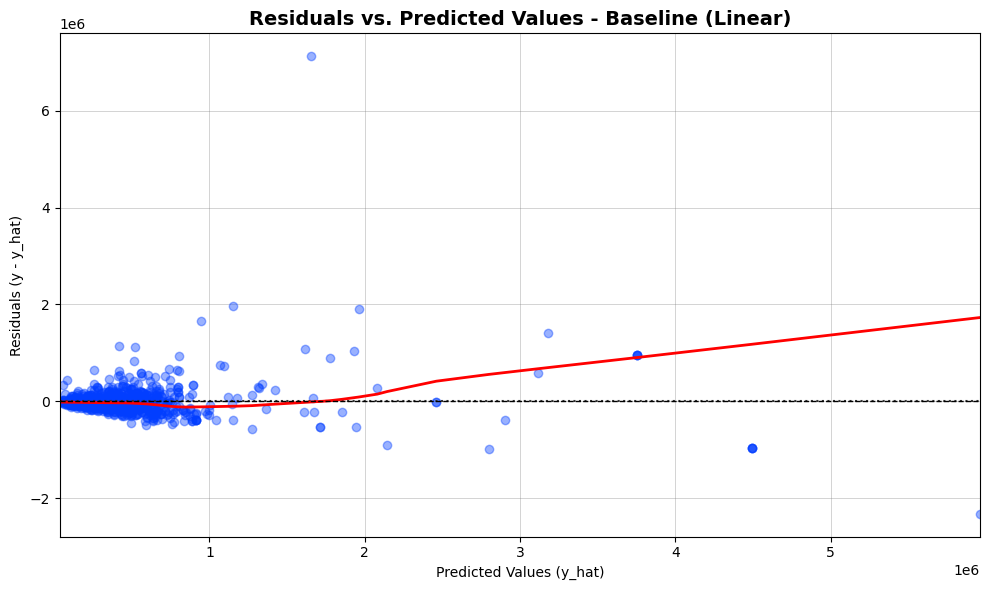

In [19]:
y_pred_flatten = y_pred_baseline.flatten()
y_true_flatten = y_test.values.flatten()

# Calculate residuals
residuals = y_true_flatten - y_pred_flatten

fig, ax = plt.subplots(figsize=(10, 6))

# 4. The Residual Plot
# 'lowess=True' adds the smoothing line to reveal hidden patterns
# 'line_kws' styles that smoothing line (red for visibility)
sns.residplot(
    x=y_pred_flatten,
    y=residuals,
    lowess=True,
    color="b",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red", "lw": 2},
    ax=ax,
)

ax.set_title(
    "Residuals vs. Predicted Values - Baseline (Linear)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Predicted Values (y_hat)")
ax.set_ylabel("Residuals (y - y_hat)")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Candidate model construction

In [20]:
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer


def make_poly2_numerical_pipe() -> Pipeline:
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ]
    )


def make_spline_numerical_pipe() -> Pipeline:
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("splines", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
        ]
    )

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge

baseline_preprocessor = make_preprocessor(categorical_cols, numerical_cols)

poly2_preprocessor = make_preprocessor(
    categorical_cols,
    numerical_cols,
    numerical_pipe=make_poly2_numerical_pipe(),
)

spline_preprocessor = make_preprocessor(
    categorical_cols,
    numerical_cols,
    numerical_pipe=make_spline_numerical_pipe(),
)

candidates = {
    "linear": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=baseline_preprocessor,
    ),
    "poly2_ridge": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=poly2_preprocessor,
    ),
    "spline_ridge": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=spline_preprocessor,
    ),
    "random_forest": make_full_pipeline(
        model=RandomForestRegressor(
            n_estimators=600,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
        preprocessor=baseline_preprocessor,
    ),
    "hist_gb": make_full_pipeline(
        model=HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=None,
            random_state=42,
        ),
        preprocessor=baseline_preprocessor,
    ),
}

In [25]:
from sklearn.model_selection import cross_validate


def evaluate_candidates(X, y, n_splits=5):
    """
    Evaluates multiple candidate models using cross-validation.
    
    Returns a DataFrame with mean and std of R², RMSE, and MAE for each model,
    sorted by RMSE (best first).
    """
    results = []
    
    for name, model in candidates.items():
        print(f"Evaluating {name}...")
        
        # Cross-validation with multiple metrics
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=n_splits,
            scoring={
                "r2": "r2",
                "neg_rmse": "neg_root_mean_squared_error",
                "neg_mae": "neg_mean_absolute_error",
            },
            n_jobs=-1,
        )
        
        # Store results (convert negative scores back to positive)
        results.append({
            "Model": name,
            "R² (mean)": cv_results["test_r2"].mean(),
            "R² (std)": cv_results["test_r2"].std(),
            "RMSE (mean)": -cv_results["test_neg_rmse"].mean(),
            "RMSE (std)": cv_results["test_neg_rmse"].std(),
            "MAE (mean)": -cv_results["test_neg_mae"].mean(),
            "MAE (std)": cv_results["test_neg_mae"].std(),
        })
    
    # Convert to DataFrame and sort by RMSE (lower is better)
    results_df = pd.DataFrame(results).sort_values("RMSE (mean)", ascending=True)
    return results_df


In [26]:
results = evaluate_candidates(X_train, y_train, n_splits=5)
display(results)

# Get the model with lowest RMSE (first row after sorting in evaluate_candidates)
best_name = results.iloc[0]["Model"]
best_model = candidates[best_name]

# Fit and predict
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
print(f"\nBest Model: {best_name}")

# Evaluate on test set
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)

print(f"Test R²: {r2_best:.4f}")
print(f"Test RMSE: {rmse_best:.4f}")
print(f"Test MAE: {mae_best:.4f}")

Evaluating linear...
Evaluating poly2_ridge...
Evaluating spline_ridge...
Evaluating random_forest...
Evaluating hist_gb...


,Model,R² (mean),R² (std),RMSE (mean),RMSE (std),MAE (mean),MAE (std)
1,poly2_ridge,0.784820,0.037228,253520.698454,32548.002196,139891.118100,6283.594300
0,linear,0.782158,0.034871,255459.422363,33081.399935,140326.128487,6794.399453
2,spline_ridge,0.779863,0.033263,256791.313023,31548.224140,140268.064676,6424.548875
3,random_forest,0.733126,0.086129,277729.872387,42497.947207,136950.221997,9380.812432
4,hist_gb,0.727575,0.066907,282771.132549,30589.396337,144850.423616,8962.565503



Best Model: poly2_ridge
Test R²: 0.7231
Test RMSE: 352449.7327
Test MAE: 153343.5779


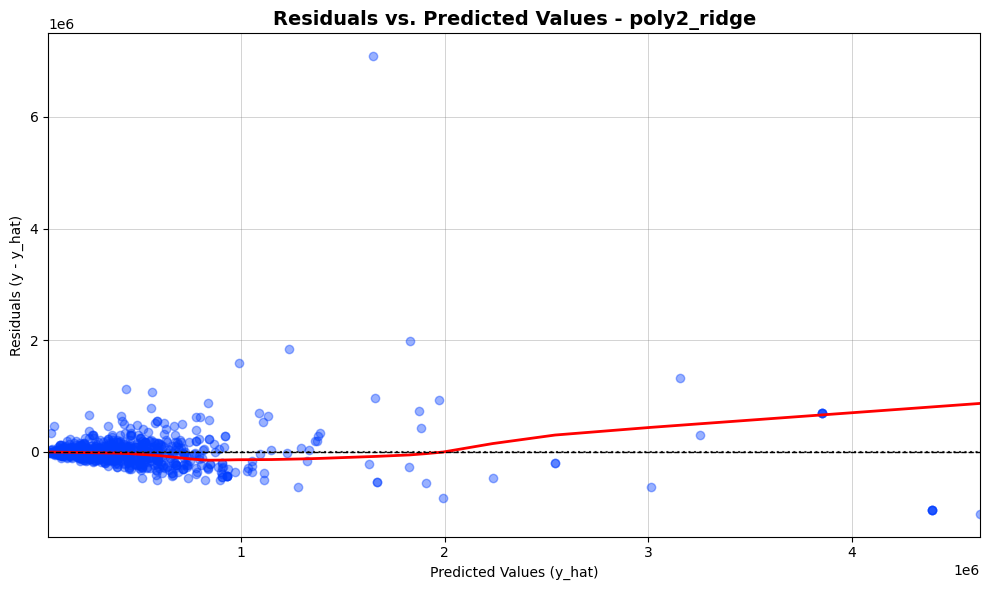

In [27]:
# Use predictions already made in the evaluation cell above
y_pred_flatten = y_pred_best.flatten()
y_true_flatten = y_test.values.flatten()

# Calculate residuals
residuals = y_true_flatten - y_pred_flatten

fig, ax = plt.subplots(figsize=(10, 6))

# Residual plot with smoothing line
sns.residplot(
    x=y_pred_flatten,
    y=residuals,
    lowess=True,
    color="b",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red", "lw": 2},
    ax=ax,
)

ax.set_title(
    f"Residuals vs. Predicted Values - {best_name}", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Predicted Values (y_hat)")
ax.set_ylabel("Residuals (y - y_hat)")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()